In [5]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")

### Agent with simple tool(create_agent)

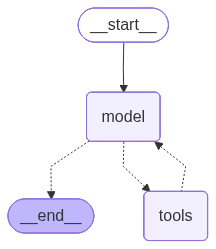

In [6]:
from langchain.agents import create_agent

def get_weather(city:str)->str:
    """Get weather for a city"""
    return f"The weather in {city}is rainy"
agent=create_agent(
    model="google_genai:gemini-2.5-flash",
    tools=[get_weather],
    system_prompt="You are a helpful assistant"
)
agent

In [7]:
agent.invoke({"messages":[{"role":"user","content":"What is weather in New York"}]})

{'messages': [HumanMessage(content='What is weather in New York', additional_kwargs={}, response_metadata={}, id='48e6fdc6-bd48-4972-9422-fbd109a33ec2'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "New York"}'}, '__gemini_function_call_thought_signatures__': {'35737c98-6acd-48f1-a675-e5a9059a3840': 'CpICAQw51seYwp5I3n6K1sZZ7G4UOUpaFWiA5cHi+91vXdubgrHwF3nlOW9n1J8naGVdMORN1TZlLVS4itxN9Y6usqpRb4cLmXBjZaqyRf0mNaF2tgMiCYIWCMocb7BTuo1WzFJdqmsCsFTPxEqw1Bd24BmpHOoXikN6aV+DnQZPR7dRu9NX5k2keFKVOteA5fy7BLww8Twycd7wB5O6KeoGvhtHZXRDvS0tefsryzvFTcKobRSOLJ0s1lPGB6PvW+8aWvdk/6QKNB8RUNywN4wEQ7iSWPRd/ASMOgA4ptKQXiiFwaUHfbTiE3Jg8po2HJtWaArxDxbQNS5spY6vtDzQspsPL8WGTn5dleTHjqKFlDjiVg=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e7412-916f-7332-9947-78d028aaff13-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id'

### Agent using init chat model

In [9]:
from langchain.chat_models import init_chat_model
model=init_chat_model("google_genai:gemini-2.5-flash")
model

ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x116984790>, default_metadata=(), model_kwargs={})

In [10]:
response=model.invoke("Hello, how are you?")
response

AIMessage(content="Hello! As an AI, I don't have feelings or a physical state, but I'm functioning perfectly and ready to assist you.\n\nHow are you doing today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e7414-4fea-7dd0-b593-37ad2aa2d1e9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 512, 'total_tokens': 519, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 476}})

### Direct model integration

In [11]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
response = model.invoke("Why do parrots talk?")
response

AIMessage(content='Parrots talk for a variety of fascinating reasons, and it\'s a complex behavior rooted in their evolutionary needs and social structures. Here\'s a breakdown of the main drivers:\n\n**1. Social Bonding and Communication:**\n\n* **Flock Animals:** Parrots are highly social creatures that live in flocks in the wild. Communication is crucial for their survival within these groups. They use calls to:\n    * **Maintain contact:** Keep track of each other when foraging or flying.\n    * **Warn of danger:** Alert the flock to predators.\n    * **Establish hierarchy:** Communicate social status.\n    * **Coordinate activities:** Signal when to fly, roost, or forage.\n* **Mimicry as a Social Tool:** In their natural environment, parrots often mimic the calls of other birds in their flock. This mimicry helps them blend in, be recognized as part of the group, and strengthen social bonds. When a parrot "talks" in a way that sounds like human speech, it\'s essentially an extensio

In [12]:
import os
from langchain_groq import ChatGroq



model = ChatGroq(model="qwen/qwen3-32b")
response = model.invoke("Why do parrots talk?")
response

AIMessage(content='<think>\nOkay, so I need to figure out why parrots talk. Let me start by recalling what I know about parrots. They\'re known for mimicking human speech, right? But why do they do that? Maybe it\'s related to communication among themselves. I remember reading that some animals use vocalizations to interact with others of their species. But parrots are unique in that they can imitate human words. \n\nFirst, I should think about the basics of animal communication. Many birds, like songbirds, use songs to attract mates or defend territory. Parrots, being social creatures, might use vocalizations to maintain social bonds. But why the ability to mimic human speech specifically? Maybe it\'s an extension of their natural ability to mimic other sounds in their environment. In the wild, they might imitate other birds, animals, or even environmental sounds like water or wind. \n\nThen there\'s the aspect of learning. Parrots are highly intelligent, so they might learn through o

### Streaming and batching

In [15]:
for i in model.stream("Write a 200 word paragraph on Langchain"):
    print(i.text, end="|",flush=True)

|<think>|
|Okay|,| I| need| to| write| a| |2|0|0|-word| paragraph| about| Lang|Chain|.| Let| me| start| by| recalling| what| Lang|Chain| is|.| It|'s| a| framework| for| developing| applications| with| large| language| models|,| right|?| So| first|,| I| should| mention| that| it|'s| designed| to| help| in| building| apps| that| use| L|LM|s|.| Maybe| talk| about| its| key| features|.| Lang|Chain| provides| tools| for| handling| prompts|,| managing| memory|,| and| working| with| different| components| like| agents|,| chains|,| and| retrie|vers|.| 

|I| should| explain| what| a| chain| is| in| this| context|—|like| a| sequence| of| operations| or| steps|.| Maybe| mention| how| chains| can| be| combined|.| Also|,| agents| and| memory| are| important| parts|.| Agents| allow| the| app| to| decide| which| tools| to| use|,| which| makes| the| application| more| dynamic|.| Memory| helps| the| app| retain| information| across| interactions|,| improving| user| experience|.

|I| should| also| touch

In [18]:
responses = model.batch([
    "Why do parrots have colorful feathers?",
    "How do airplanes fly?",
    "What is quantum computing?"],
    config={
        'max_concurrency':5
    }
)
for i in responses:
    print(i)

content="<think>\nOkay, so the user is asking why parrots have colorful feathers. Let me start by recalling what I know about parrots. Parrots are known for their bright colors, like reds, blues, yellows, and greens. I think their coloration has something to do with their environment and behavior. \n\nFirst, maybe it's for camouflage. But wait, parrots are in tropical regions with lots of green foliage. If they're green or have similar colors, maybe they blend in. But why are there so many different colors? Some parrots have very striking colors that don't obviously match their surroundings. Maybe it's not just camouflage.\n\nAnother thought is sexual selection. Like in many animals, males might have brighter colors to attract females. I remember reading that in some bird species, males are more colorful to show their health and genetic quality. If a parrot's bright feathers indicate it's strong and disease-free, females might choose those mates. But do both males and females have colo